In [1]:
from helpers import init, preprocess_data

In [2]:
SEED = 42
X_train_raw, y_train_cm, X_val_raw, y_val_cm = init(SEED)
X_train, y_train, X_val, y_val, target_min_cm, target_range_cm = preprocess_data(X_train_raw, y_train_cm, X_val_raw, y_val_cm)

PyTorch: 2.11.0+cu130
Training rows: 42166
Validation rows: 4685
Input shape: (42166, 9)
Target x range (cm): 0.0 to 281.0
Target y range (cm): 0.0 to 275.0
Using split files:
  train: train_clean_3x3_1cm.csv 42166 rows
  validation: validation_clean_3x3_1cm.csv 4685 rows
RSS scale: 0.8493868112564087
Target min cm: [0. 0.]
Target range cm: [281. 275.]


# Get the model

In [3]:
from vlp_hackathon.baseline_model import BaselineMLP
from vlp_hackathon.improved_model import ImprovedMLP
model_cls = ImprovedMLP

# Run a trail

In [4]:
from torch import nn
import torch
import numpy as np
from matplotlib import pyplot as plt
import copy

def train_model(model, optimizer, loss_fn, epochs, batch_size, plot: bool = False, ret_model: bool = False):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    X_train_t = torch.from_numpy(X_train).to(device)
    y_train_t = torch.from_numpy(y_train).to(device)
    X_val_t = torch.from_numpy(X_val).to(device)
    y_val_t = torch.from_numpy(y_val).to(device)
    model = model.to(device)

    history = []
    best_model = copy.deepcopy(model)
    lowest_loss = float("inf")
    train_rng = np.random.default_rng(SEED)
    for epoch in range(epochs):
        model.train()
        permutation = train_rng.permutation(len(X_train))
        running = 0.0
        for start in range(0, len(permutation), batch_size):
            idx = permutation[start:start + batch_size]
            xb = X_train_t[idx]
            yb = y_train_t[idx]
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            if loss < lowest_loss:
                best_model = copy.deepcopy(model)
            optimizer.step()
            running += float(loss.item()) * len(idx)

        model.eval()
        with torch.no_grad():
            val_loss = float(loss_fn(model(X_val_t), y_val_t).item())
        history.append((running / len(X_train), val_loss))
        print(f"epoch={epoch + 1:02d} train_mse={history[-1][0]:.6f} val_mse={val_loss:.6f}")

    history = np.asarray(history, dtype=np.float32)
    if plot:
        plt.figure(figsize=(6, 4))
        plt.plot(history[:, 0], label="train")
        plt.plot(history[:, 1], label="validation")
        plt.xlabel("Epoch")
        plt.ylabel("MSE on normalized coordinates")
        plt.legend()
        plt.title("Baseline training curve")
        plt.show()

    if ret_model:
        return best_model
    return np.min(history[:, 1])

def run_trial(trial):
    epochs = 40

    print(trial)
    lr = trial.suggest_float("lr", 1e-5, 1e-1, log=True)
    batch_size = trial.suggest_int("batch_size", 16, 4096)

    depth = trial.suggest_int("depth", 1, 6)
    layers = []
    for layer in range(depth):
        width = trial.suggest_int(f"layer_{layer}", 2, 128)
        layers.append(width)

    # Start and end are fixed
    layers = [9] + layers + [2]

    act = trial.suggest_categorical("act", ["relu", "tanh", "sigmoid", ""])
    last_act = trial.suggest_categorical("last_act", ["relu", "tanh", "sigmoid", ""])
    layer_norm = trial.suggest_categorical("layer_norm", [True, False])

    model = model_cls(layers=layers, activation=act, last_act=last_act, layer_norm=layer_norm)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    return train_model(model, optimizer, loss_fn, epochs, batch_size)

In [5]:
import optuna
from optuna.trial import TrialState

study = optuna.create_study(direction='minimize', study_name="task_1", load_if_exists=True, storage="sqlite:///trail_1.db")
study.optimize(run_trial, n_trials=1, show_progress_bar=True)

pruned_trials = study.get_trials(deepcopy=False, states=[TrialState.PRUNED])
complete_trials = study.get_trials(deepcopy=False, states=[TrialState.COMPLETE])

print("Study statistics: ")
print("  Number of finished trials: ", len(study.trials))
print("  Number of pruned trials: ", len(pruned_trials))
print("  Number of complete trials: ", len(complete_trials))

print("Best trial:")
trial = study.best_trial

print("  Value: ", trial.value)

print("  Params: ")
for key, value in trial.params.items():
    print("    {}: {}".format(key, value))

[I 2026-07-08 16:45:44,634] Using an existing study with name 'task_1' instead of creating a new one.


  0%|          | 0/1 [00:00<?, ?it/s]

Sequential(
  (0): Linear(in_features=9, out_features=89, bias=True)
  (1): LayerNorm((89,), eps=1e-05, elementwise_affine=True)
  (2): ReLU()
  (3): Linear(in_features=89, out_features=113, bias=True)
  (4): LayerNorm((113,), eps=1e-05, elementwise_affine=True)
  (5): ReLU()
  (6): Linear(in_features=113, out_features=2, bias=True)
  (7): Tanh()
)
epoch=01 train_mse=0.556351 val_mse=0.394579
epoch=02 train_mse=0.300334 val_mse=0.206760
epoch=03 train_mse=0.162396 val_mse=0.118339
epoch=04 train_mse=0.099961 val_mse=0.079601
epoch=05 train_mse=0.071427 val_mse=0.060319
epoch=06 train_mse=0.055783 val_mse=0.048293
epoch=07 train_mse=0.045135 val_mse=0.039248
epoch=08 train_mse=0.036841 val_mse=0.032006
epoch=09 train_mse=0.030097 val_mse=0.025961
epoch=10 train_mse=0.024450 val_mse=0.020987
epoch=11 train_mse=0.019845 val_mse=0.016955
epoch=12 train_mse=0.016073 val_mse=0.013641
epoch=13 train_mse=0.013024 val_mse=0.011041
epoch=14 train_mse=0.010713 val_mse=0.009148
epoch=15 train_mse=

In [6]:
from plotly.io import show

fig = optuna.visualization.plot_optimization_history(study)
show(fig)

fig = optuna.visualization.plot_param_importances(study)
show(fig)

fig = optuna.visualization.plot_slice(study)
show(fig)

# Make the best model

{'lr': 0.0010934026768884433, 'batch_size': 50, 'depth': 3, 'layer_0': 113, 'layer_1': 90, 'layer_2': 93, 'act': 'relu', 'last_act': 'tanh'}
Sequential(
  (0): Linear(in_features=9, out_features=113, bias=True)
  (1): LayerNorm((113,), eps=1e-05, elementwise_affine=True)
  (2): ReLU()
  (3): Linear(in_features=113, out_features=90, bias=True)
  (4): LayerNorm((90,), eps=1e-05, elementwise_affine=True)
  (5): ReLU()
  (6): Linear(in_features=90, out_features=93, bias=True)
  (7): LayerNorm((93,), eps=1e-05, elementwise_affine=True)
  (8): ReLU()
  (9): Linear(in_features=93, out_features=2, bias=True)
  (10): Tanh()
)
epoch=01 train_mse=0.001252 val_mse=0.000166
epoch=02 train_mse=0.000089 val_mse=0.000072
epoch=03 train_mse=0.000081 val_mse=0.000055
epoch=04 train_mse=0.000058 val_mse=0.000037
epoch=05 train_mse=0.000057 val_mse=0.000033
epoch=06 train_mse=0.000052 val_mse=0.000119
epoch=07 train_mse=0.000050 val_mse=0.000040
epoch=08 train_mse=0.000039 val_mse=0.000022
epoch=09 train_

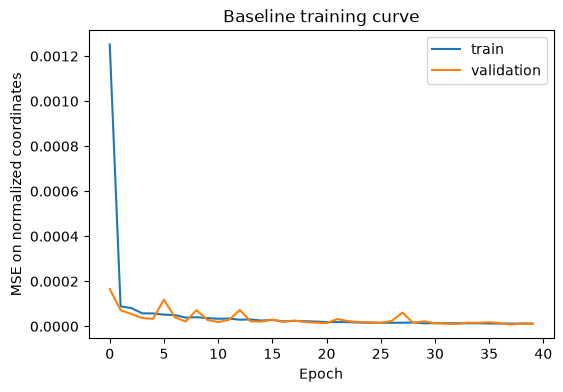

In [7]:
best_params = study.best_params
print(best_params)

layers = []
for layer_idx in range(best_params["depth"]):
    layer_name = f"layer_{layer_idx}"
    layer_size = best_params[layer_name]
    layers.append(layer_size)
layers = [9] + layers + [2]
best_model = model_cls(layers=layers, activation=best_params["act"], last_act=best_params["last_act"])

epochs = 40
batch_size = best_params["batch_size"]
optimizer = torch.optim.Adam(best_model.parameters(), lr=best_params["lr"])
loss_fn = nn.MSELoss()
best_model = train_model(best_model, optimizer, loss_fn, epochs, batch_size, plot=True, ret_model=True)

# Make the baseline model

epoch=01 train_mse=0.087113 val_mse=0.066191
epoch=02 train_mse=0.035969 val_mse=0.011517
epoch=03 train_mse=0.008945 val_mse=0.006894
epoch=04 train_mse=0.006367 val_mse=0.005191
epoch=05 train_mse=0.004728 val_mse=0.003763
epoch=06 train_mse=0.003501 val_mse=0.002883
epoch=07 train_mse=0.002683 val_mse=0.002194
epoch=08 train_mse=0.002031 val_mse=0.001656
epoch=09 train_mse=0.001528 val_mse=0.001258
epoch=10 train_mse=0.001196 val_mse=0.001023
epoch=11 train_mse=0.000999 val_mse=0.000877
epoch=12 train_mse=0.000872 val_mse=0.000782
epoch=13 train_mse=0.000783 val_mse=0.000708
epoch=14 train_mse=0.000715 val_mse=0.000651
epoch=15 train_mse=0.000660 val_mse=0.000605
epoch=16 train_mse=0.000611 val_mse=0.000560
epoch=17 train_mse=0.000570 val_mse=0.000527
epoch=18 train_mse=0.000533 val_mse=0.000496
epoch=19 train_mse=0.000503 val_mse=0.000468
epoch=20 train_mse=0.000474 val_mse=0.000440
epoch=21 train_mse=0.000449 val_mse=0.000418
epoch=22 train_mse=0.000426 val_mse=0.000397
epoch=23 t

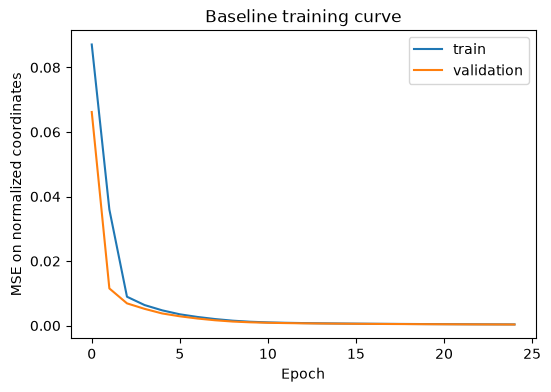

In [8]:
original_model = BaselineMLP(input_features=9)
history = []
epochs = 25
batch_size = 512
optimizer = torch.optim.Adam(original_model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
original_model = train_model(original_model, optimizer, loss_fn, epochs, batch_size, plot=True, ret_model=True)

# Compare performance


original:
Float validation mean error:   5.743 cm
Float validation median error: 4.526 cm
Float validation p95 error:    15.785 cm

best:
Float validation mean error:   1.133 cm
Float validation median error: 1.038 cm
Float validation p95 error:    2.272 cm


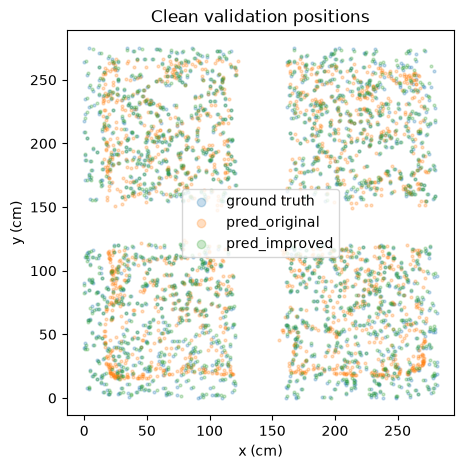

In [9]:
from vlp_hackathon.metrics import euclidean_errors_cm

def eval_model(model, name: str):
    model.eval()
    with torch.no_grad():
        float_norm = model(torch.from_numpy(X_val)).numpy()
    float_pred_cm = target_min_cm + float_norm * target_range_cm
    float_errors = euclidean_errors_cm(float_pred_cm, y_val_cm)

    print(f"\n{name}:")
    print(f"Float validation mean error:   {float_errors.mean():.3f} cm")
    print(f"Float validation median error: {np.median(float_errors):.3f} cm")
    print(f"Float validation p95 error:    {np.percentile(float_errors, 95):.3f} cm")
    return float_pred_cm

errors = []
for model, name in [(original_model, "original"), (best_model, "best")]:
    errors.append(eval_model(model, name))

plt.figure(figsize=(5, 5))
n_show = min(1500, len(y_val_cm))
plt.scatter(y_val_cm[:n_show, 0], y_val_cm[:n_show, 1], s=4, alpha=0.25, label="ground truth")
plt.scatter(errors[0][:n_show, 0], errors[0][:n_show, 1], s=4, alpha=0.25, label="pred_original")
plt.scatter(errors[1][:n_show, 0], errors[1][:n_show, 1], s=4, alpha=0.25, label="pred_improved")
plt.xlabel("x (cm)")
plt.ylabel("y (cm)")
plt.legend(markerscale=3)
plt.title("Clean validation positions")
plt.show()